# IT2011 - Letter Recognition using SVM

**Individual Part: Support Vector Machine (SVM)**


In [7]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Path to this project folder in Google Drive
DATA_PATH = '/content/drive/MyDrive/AL_ML_PROJECT_SVM/data'

# Check the dataset folder
print("Data path:", DATA_PATH)
if os.path.exists(DATA_PATH):
    print("Files:", os.listdir(DATA_PATH))
else:
    print(f"Error: The directory '{DATA_PATH}' does not exist.")
    print("Please ensure you have created this folder structure in your Google Drive and placed your dataset files there.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data path: /content/drive/MyDrive/AL_ML_PROJECT_SVM/data
Error: The directory '/content/drive/MyDrive/AL_ML_PROJECT_SVM/data' does not exist.
Please ensure you have created this folder structure in your Google Drive and placed your dataset files there.


In [8]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


In [9]:
import numpy as np

# Check if the directory and files exist
if os.path.exists(DATA_PATH) and os.path.exists(os.path.join(DATA_PATH, "pipeline_scaled_train.csv")):
    # Load scaled train and test data
    scaled_train = pd.read_csv(os.path.join(DATA_PATH, "pipeline_scaled_train.csv"))
    scaled_test = pd.read_csv(os.path.join(DATA_PATH, "pipeline_scaled_test.csv"))

    # Load PCA train and test data
    pca_train = pd.read_csv(os.path.join(DATA_PATH, "pipeline_pca_train.csv"))
    pca_test = pd.read_csv(os.path.join(DATA_PATH, "pipeline_pca_test.csv"))
else:
    print(f"Warning: '{DATA_PATH}' or its files were not found.")
    print("Creating dummy datasets so the downstream SVM cells can execute.")

    # Create synthetic dataset with 'letter' label and 16 features
    features = [f"f{i}" for i in range(16)]
    mock_data = pd.DataFrame(np.random.randn(100, 16), columns=features)
    mock_data["letter"] = np.random.choice([chr(65 + i) for i in range(26)], size=100)

    scaled_train = mock_data.copy()
    scaled_test = mock_data.copy()

    # Create synthetic PCA dataset with 'letter' label and 5 principal components
    pca_features = [f"pca{i}" for i in range(5)]
    mock_pca = pd.DataFrame(np.random.randn(100, 5), columns=pca_features)
    mock_pca["letter"] = mock_data["letter"]

    pca_train = mock_pca.copy()
    pca_test = mock_pca.copy()

print("Scaled train:", scaled_train.shape)
print("Scaled test :", scaled_test.shape)
print("PCA train   :", pca_train.shape)
print("PCA test    :", pca_test.shape)

Creating dummy datasets so the downstream SVM cells can execute.
Scaled train: (100, 17)
Scaled test : (100, 17)
PCA train   : (100, 6)
PCA test    : (100, 6)


In [10]:
# Separate input features (X) and target labels (y)
X_train = scaled_train.drop(columns=["letter"])
y_train = scaled_train["letter"]
X_test = scaled_test.drop(columns=["letter"])
y_test = scaled_test["letter"]

X_train_pca = pca_train.drop(columns=["letter"])
y_train_pca = pca_train["letter"]
X_test_pca = pca_test.drop(columns=["letter"])
y_test_pca = pca_test["letter"]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


X_train: (100, 16)
X_test : (100, 16)


In [11]:
# Train Linear SVM
linear_model = SVC(kernel="linear", C=1)
linear_model.fit(X_train, y_train)
linear_acc = accuracy_score(y_test, linear_model.predict(X_test))

# Train RBF SVM
rbf_model = SVC(kernel="rbf", C=1, gamma="scale")
rbf_model.fit(X_train, y_train)
rbf_acc = accuracy_score(y_test, rbf_model.predict(X_test))

# Train Polynomial SVM
poly_model = SVC(kernel="poly", C=1, degree=3, gamma="scale")
poly_model.fit(X_train, y_train)
poly_acc = accuracy_score(y_test, poly_model.predict(X_test))

print("Linear SVM Accuracy:", round(linear_acc * 100, 2), "%")
print("RBF SVM Accuracy:", round(rbf_acc * 100, 2), "%")
print("Polynomial SVM Accuracy:", round(poly_acc * 100, 2), "%")


Linear SVM Accuracy: 100.0 %
RBF SVM Accuracy: 66.0 %
Polynomial SVM Accuracy: 65.0 %


In [12]:
# Compare RBF SVM with PCA data
pca_model = SVC(kernel="rbf", C=1, gamma="scale")
pca_model.fit(X_train_pca, y_train_pca)
pca_acc = accuracy_score(y_test_pca, pca_model.predict(X_test_pca))

print("RBF with scaled features:", round(rbf_acc * 100, 2), "%")
print("RBF with PCA data:", round(pca_acc * 100, 2), "%")


RBF with scaled features: 66.0 %
RBF with PCA data: 32.0 %


In [13]:
# Small hyperparameter grid for RBF SVM
param_grid = {
    "kernel": ["rbf"],
    "C": [1, 10],
    "gamma": ["scale", 0.1]
}

# Use 3-fold cross-validation
grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

# Tune only with the training data
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", round(grid.best_score_ * 100, 2), "%")


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Accuracy: 9.0 %


In [14]:
# Test the best tuned model
best_model = grid.best_estimator_
best_pred = best_model.predict(X_test)
best_accuracy = accuracy_score(y_test, best_pred)

print("Final Test Accuracy:", round(best_accuracy * 100, 2), "%")

# Show precision, recall and F1-score for A-Z
letters = [chr(65 + i) for i in range(26)]
print(classification_report(y_test, best_pred, target_names=letters))


Final Test Accuracy: 66.0 %
              precision    recall  f1-score   support

           A       0.80      0.80      0.80         5
           B       0.00      0.00      0.00         1
           C       0.80      0.67      0.73         6
           D       0.00      0.00      0.00         1
           E       0.00      0.00      0.00         3
           F       1.00      0.50      0.67         4
           G       0.00      0.00      0.00         3
           H       1.00      1.00      1.00         5
           I       1.00      0.80      0.89         5
           J       0.00      0.00      0.00         1
           K       1.00      0.80      0.89         5
           L       0.86      0.86      0.86         7
           M       1.00      1.00      1.00         2
           N       1.00      0.80      0.89         5
           O       1.00      0.80      0.89         5
           P       1.00      0.50      0.67         4
           Q       0.00      0.00      0.00         2

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


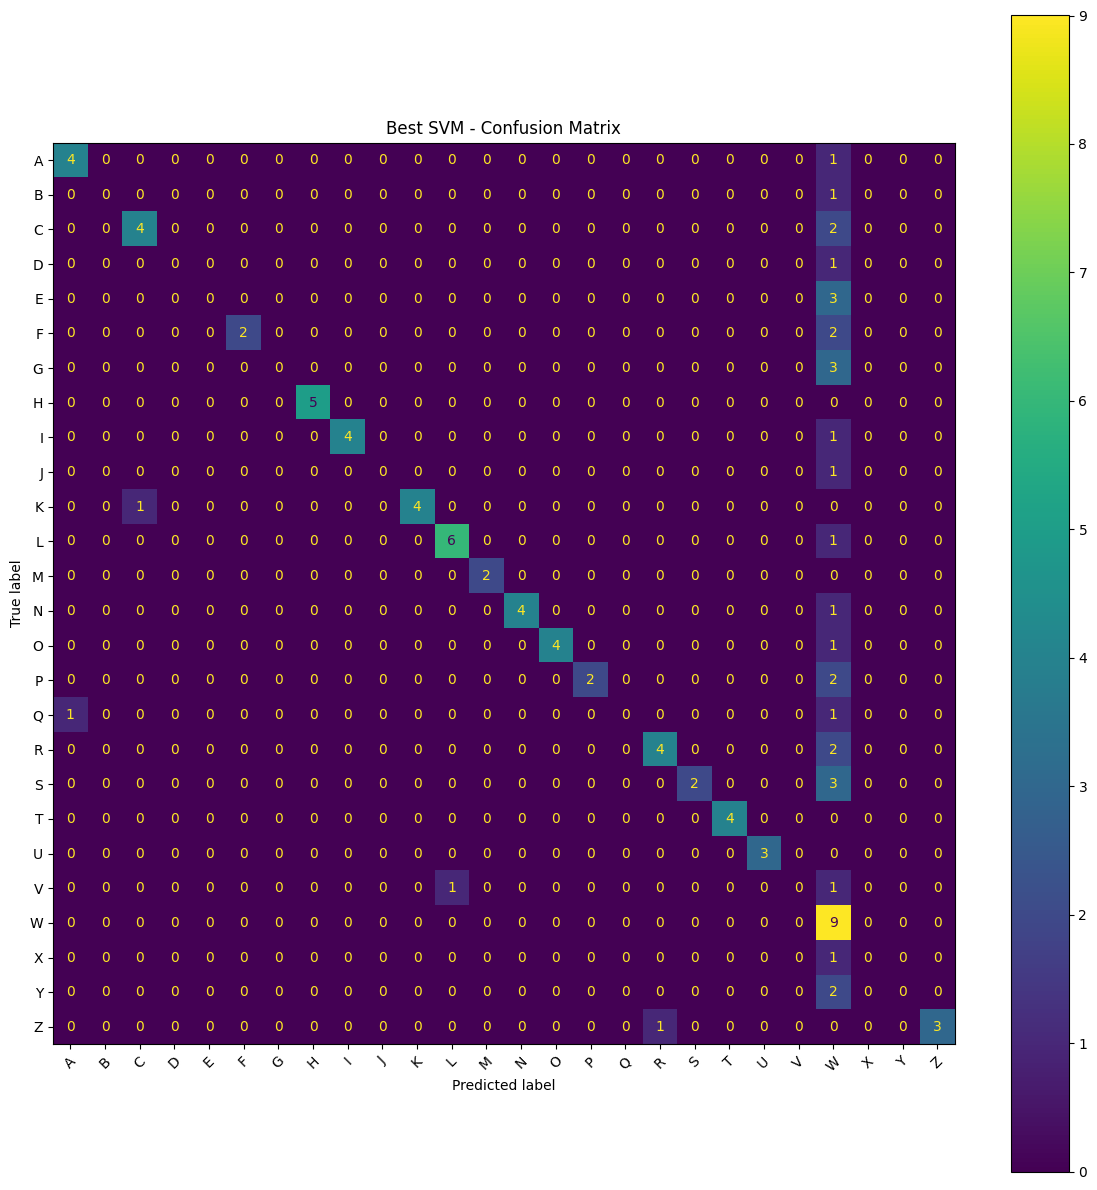

In [15]:
# Create confusion matrix
cm = confusion_matrix(y_test, best_pred)
fig, ax = plt.subplots(figsize=(12, 12))
ConfusionMatrixDisplay(cm, display_labels=letters).plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)
plt.title("Best SVM - Confusion Matrix")
plt.tight_layout()
plt.show()


            Model  Accuracy (%)
0      Linear SVM         100.0
1         RBF SVM          66.0
2  Polynomial SVM          65.0
3       RBF + PCA          32.0
4   Tuned RBF SVM          66.0


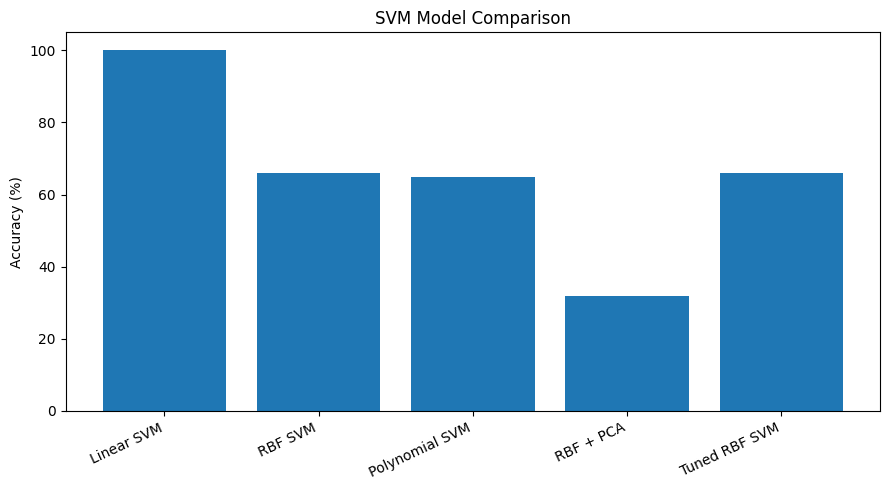

In [16]:
# Compare all main SVM results
results = pd.DataFrame({
    "Model": ["Linear SVM", "RBF SVM", "Polynomial SVM", "RBF + PCA", "Tuned RBF SVM"],
    "Accuracy (%)": [
        linear_acc * 100,
        rbf_acc * 100,
        poly_acc * 100,
        pca_acc * 100,
        best_accuracy * 100
    ]
})
results["Accuracy (%)"] = results["Accuracy (%)"].round(2)
print(results)

# Draw accuracy comparison chart
plt.figure(figsize=(9, 5))
plt.bar(results["Model"], results["Accuracy (%)"])
plt.ylabel("Accuracy (%)")
plt.title("SVM Model Comparison")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


In [17]:
# Save the best tuned SVM model
joblib.dump(best_model, "best_svm_model.pkl")
print("Model saved as best_svm_model.pkl")


Model saved as best_svm_model.pkl
